# Splines de regresión con funciones base

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from ISLP import load_data

from ISLP.models import (
    ModelSpec as MS,
    summarize,
    bs,
    ns,
    poly
)

from ISLP.transforms import (
    BSpline,
    NaturalSpline
)

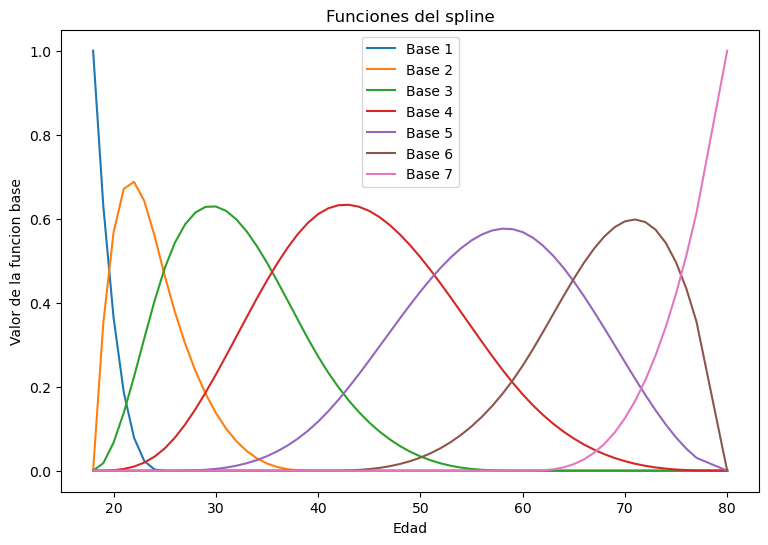

In [2]:
Wage = load_data('Wage')
age = Wage['age']
wage = Wage['wage']

#Trasnformamos con bs
bs_transform = BSpline(internal_knots = [25,40,60], intercept = True)
bs_transform = bs_transform.fit(age)
#Transformamos con el predictor
bs_age= bs_transform.transform(age)

#Grafica de la base de spline
age_order = np.argsort(age.to_numpy())
age_sorted = age.to_numpy()[age_order]

bs_sorted = bs_age.iloc[age_order,:].to_numpy()

plt.figure(figsize = (9,6))
for j in range(bs_sorted.shape[1]):
    plt.plot(age_sorted,bs_sorted[:,j],
    label = f"Base {j+1}")
plt.title("Funciones del spline")
plt.xlabel("Edad")
plt.ylabel("Valor de la funcion base")
plt.legend()
plt.show()

In [3]:
#Ajustar
bs_age_spec = MS([bs("age", internal_knots = [25,40,60])])
bs_age_spec = bs_age_spec.fit(Wage)
x_bs = bs_age_spec.transform(Wage)
model_bs = sm.OLS(wage,x_bs).fit()
model_bs.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     47.19
Date:                Tue, 01 Sep 2026   Prob (F-statistic):           1.53e-55
Time:                        10:37:02   Log-Likelihood:                -15314.
No. Observations:                3000   AIC:                         3.064e+04
Df Residuals:                    2993   BIC:                         3.068e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===========================================================================================================
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
intercept                                  60.4937      9.460      6.394      0.000      41.944      79.043
bs(age, internal_knots=[25, 40, 60])[0]     3.9805     12.538      0.317      0.751     -20.603      28.564
bs(age, internal_knots=[25, 40, 60])[1]    44.6310      9.626      4.636      0.000      25.756      63.506
bs(age, internal_knots=[25, 40, 60])[2]    62.8388     10.755      5.843      0.000      41.750      83.927
bs(age, internal_knots=[25, 40, 60])[3]    55.9908     10.706      5.230      0.000      34.998      76.983
bs(age, internal_knots=[25, 40, 60])[4]    50.6881     14.402      3.520      0.000      22.450      78.927
bs(age, internal_knots=[25, 40, 60])[5]    16.6061     19.126      0.868      0.385     -20.896      54.108
==============================================================================
Omnibus:                     1096.233   Durbin-Watson:                   1.962
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4953.521
Skew:                           1.720   Prob(JB):                         0.00
Kurtosis:                       8.273   Cond. No.                         41.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

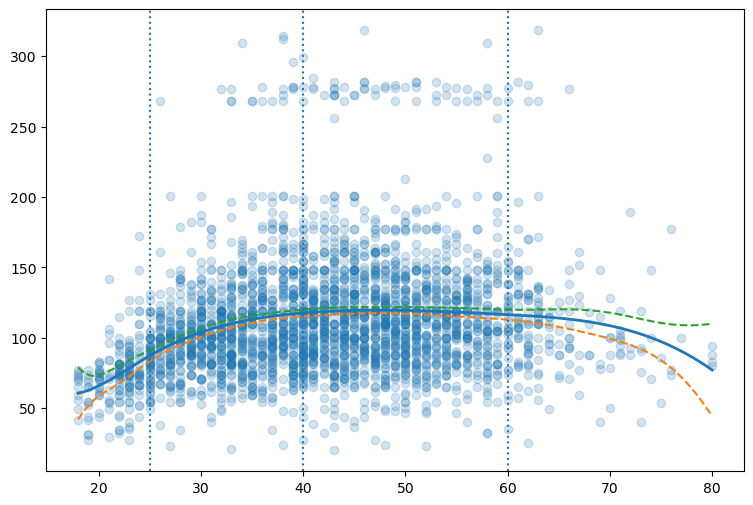

In [5]:

#Creación del grid del modelo entrenado
age_grid = np.linspace(age.min(),age.max(), 500)
age_grid_df = pd.DataFrame({'age': age_grid})

X_grid_bs = bs_age_spec.transform(age_grid_df)
pred_bs = model_bs.get_prediction(X_grid_bs)
pred_bs_summary = pred_bs.summary_frame()
#Creacion de dataframe de intervalos de confianza
pred_bs_summary.head()


#Gráfica
plt.figure(figsize = (9,6))
plt.scatter(age, wage, alpha = 0.2)
plt.plot(age_grid, pred_bs_summary['mean'], linewidth = 2)
plt.plot(age_grid, pred_bs_summary['mean_ci_lower'], linestyle = "--")
plt.plot(age_grid, pred_bs_summary['mean_ci_upper'], linestyle = '--')
plt.axvline(25, linestyle = ":")
plt.axvline(40, linestyle = ":")
plt.axvline(60, linestyle = ":")

plt.show()

In [12]:
#Ajustar respecto a los grados de libertad
bs_df6 = BSpline(df=6).fit(age)
print(bs_df6.internal_knots_)
print(age.quantile([.25,.50,.75]))

[33.75 42.   51.  ]
0.25    33.75
0.50    42.00
0.75    51.00
Name: age, dtype: float64


In [16]:
#Ajustar respecto a ms y grados de libertad
bs_df_spec = MS([bs('age',df=6)]).fit(Wage)
x_bs_df = bs_df_spec.transform(Wage)
model_bs_df = sm.OLS(wage,x_bs_df).fit()
summarize(model_bs_df)

,coef,std err,t,P>|t|
intercept,56.3138,7.258,7.759,0.000
"bs(age, df=6)[0]",27.8240,12.435,2.238,0.025
"bs(age, df=6)[1]",54.0625,7.127,7.585,0.000
"bs(age, df=6)[2]",65.8284,8.323,7.909,0.000
"bs(age, df=6)[3]",55.8127,8.724,6.398,0.000
"bs(age, df=6)[4]",72.1315,13.745,5.248,0.000
"bs(age, df=6)[5]",14.7509,16.209,0.910,0.363


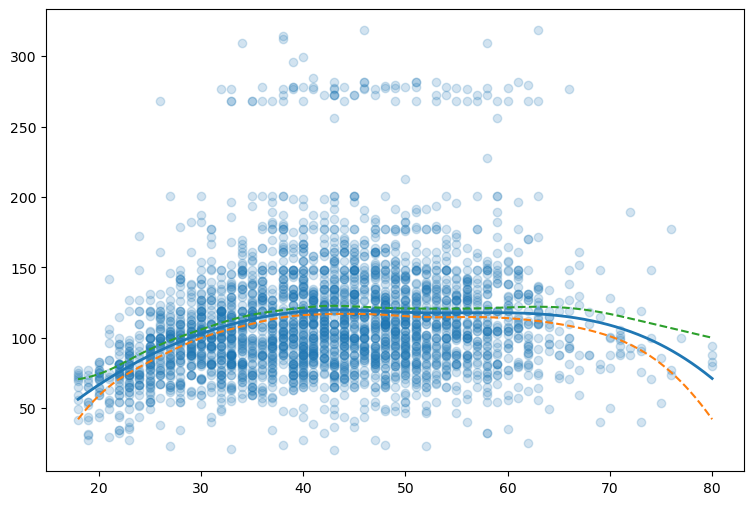

In [19]:
#Grafica
x_grid_bs_df = bs_df_spec.transform(age_grid_df)
pred_bs_df = model_bs_df.get_prediction(x_grid_bs_df).summary_frame()

#Gráfica
plt.figure(figsize = (9,6))
plt.scatter(age, wage, alpha = 0.2)
plt.plot(age_grid, pred_bs_df['mean'], linewidth = 2)
plt.plot(age_grid, pred_bs_df['mean_ci_lower'], linestyle = "--")
plt.plot(age_grid, pred_bs_df['mean_ci_upper'], linestyle = '--')

plt.show()

In [22]:
bs_degree0_spec = MS([bs('age', df = 3, degree = 0)]).fit(Wage)
x_degree0 = bs_degree0_spec.transform(Wage)
model_degree0 = sm.OLS(wage,x_degree0).fit()
summarize(model_degree0)

,coef,std err,t,P>|t|
intercept,94.1584,1.478,63.687,0.0
"bs(age, df=3, degree=0)[0]",22.3490,2.152,10.388,0.0
"bs(age, df=3, degree=0)[1]",24.8076,2.044,12.137,0.0
"bs(age, df=3, degree=0)[2]",22.7814,2.087,10.917,0.0


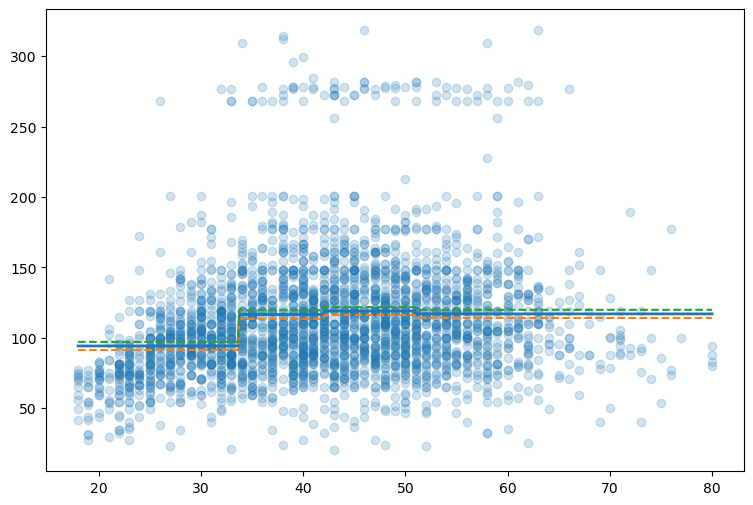

In [23]:
#Grafica
x_grid_bs_df = bs_degree0_spec.transform(age_grid_df)
pred_bs_df = model_degree0.get_prediction(x_grid_bs_df).summary_frame()

#Gráfica
plt.figure(figsize = (9,6))
plt.scatter(age, wage, alpha = 0.2)
plt.plot(age_grid, pred_bs_df['mean'], linewidth = 2)
plt.plot(age_grid, pred_bs_df['mean_ci_lower'], linestyle = "--")
plt.plot(age_grid, pred_bs_df['mean_ci_upper'], linestyle = '--')

plt.show()

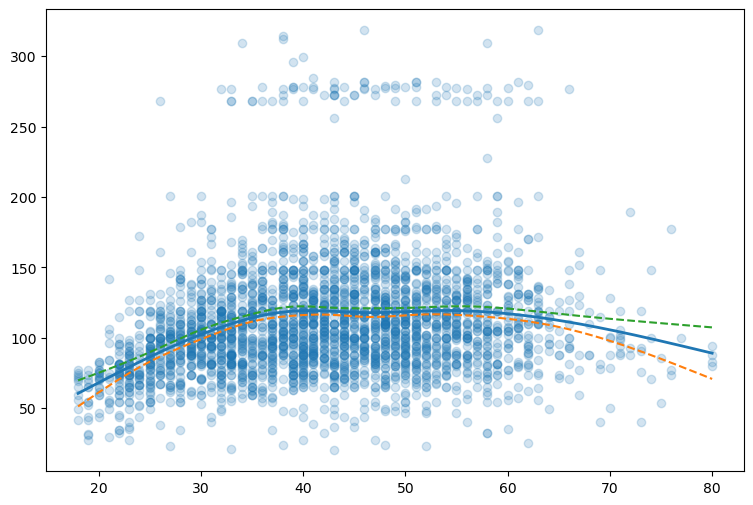

In [26]:
#spline natural
ns_age_spec = MS([ns("age",df = 5)]).fit(Wage)
x_ns = ns_age_spec.transform(Wage)
model_ns = sm.OLS(wage,x_ns).fit()
#Grafica
x_grid_bs_df = ns_age_spec.transform(age_grid_df)
pred_bs_df = model_ns.get_prediction(x_grid_bs_df).summary_frame()

#Gráfica
plt.figure(figsize = (9,6))
plt.scatter(age, wage, alpha = 0.2)
plt.plot(age_grid, pred_bs_df['mean'], linewidth = 2)
plt.plot(age_grid, pred_bs_df['mean_ci_lower'], linestyle = "--")
plt.plot(age_grid, pred_bs_df['mean_ci_upper'], linestyle = '--')

plt.show()

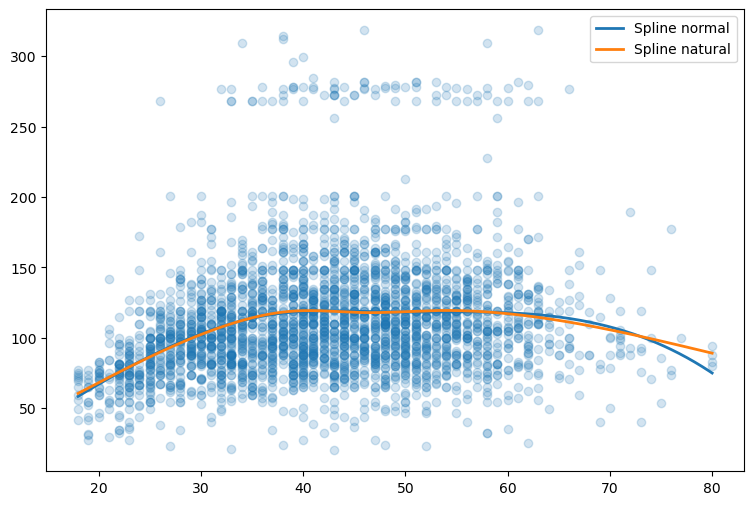

In [32]:
#Spline normal con 5 grados de libertad y spline natural

#Spline normal
bs_df_spec = MS([bs('age',df=5)]).fit(Wage)
x_bs_df = bs_df_spec.transform(Wage)
model_bs_df = sm.OLS(wage,x_bs_df).fit()

x_age_bs_df = bs_df_spec.transform(age_grid_df)
pred_bs_df = model_bs_df.get_prediction(x_age_bs_df).summary_frame()

#Spline natural
ns_df_spec = MS([ns('age',df=5)]).fit(Wage)
x_ns_df = ns_df_spec.transform(Wage)
model_ns_df = sm.OLS(wage,x_ns_df).fit()

x_age_ns_df = ns_df_spec.transform(age_grid_df)
pred_ns_df = model_ns_df.get_prediction(x_age_ns_df).summary_frame()



#Gráfica
plt.figure(figsize = (9,6))
plt.scatter(age, wage, alpha = 0.2)
plt.plot(age_grid, pred_bs_df['mean'], linewidth = 2, label = "Spline normal")
plt.plot(age_grid, pred_ns_df['mean'], linewidth = 2, label = "Spline natural")
plt.legend()
plt.show()

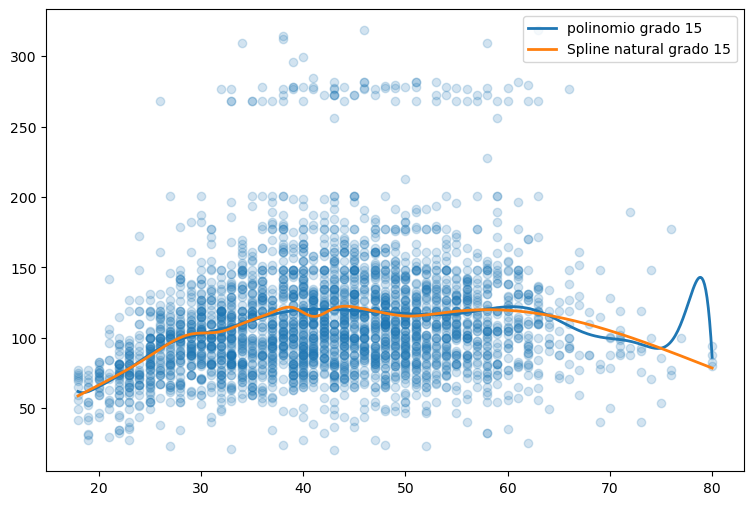

In [43]:
poly15_spec = MS([poly('age',degree = 15)]).fit(Wage)
model_poly15 = sm.OLS(wage, poly15_spec.transform(Wage)).fit()

ns15_spec = MS([ns("age", df = 15)]).fit(Wage)
model_ns15 = sm.OLS(wage, ns15_spec.transform(Wage)).fit()

pred_poly15 = model_poly15.predict(poly15_spec.transform(age_grid_df))
pred_ns15 = model_ns15.predict(ns15_spec.transform(age_grid_df))

#Gráfica
plt.figure(figsize = (9,6))
plt.scatter(age, wage, alpha = 0.2)
plt.plot(age_grid, pred_poly15, linewidth = 2, label = "polinomio grado 15")
plt.plot(age_grid, pred_ns15, linewidth = 2, label = "Spline natural grado 15")
plt.legend()
plt.show()

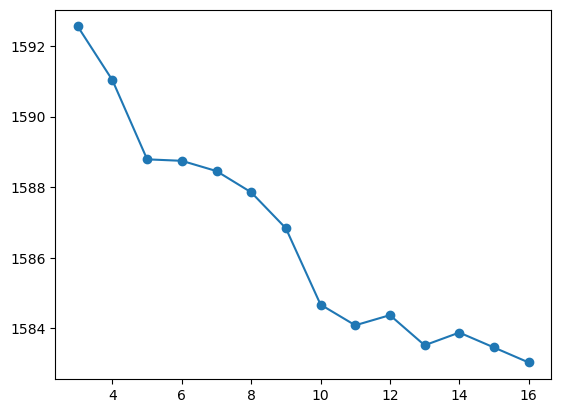

In [55]:
MSE = []

for i in range(3,17):
    bs_spec = MS([bs("age", df = i)]).fit(Wage)
    X=bs_spec.transform(Wage)
    model_bs = sm.OLS(wage, X).fit()
    
    pred_bs = model_bs.predict(X)
    
    err = (wage - pred_bs)**2
    MSE.append(np.mean(err))

plt.plot(range(3,17),MSE, marker = "o")